<a id='table_of_contents'></a>  
<a id="section_ID">0.</a> [Import libraries](#imports)  
<a id="section_ID">1.</a> [Import data](#import_data)  
<a id="section_ID">2.</a> [Data exploration](#data_exploration)  
<a id="section_ID">3.</a> [Data cleaning](#data_cleaning)  
<a id="section_ID">4.</a> [Data preparation](#data_preparation)  
<a id="section_ID">5.</a> [Benchmark model](#benchmark_model)  
>>  <a id="section_ID">5.1.</a> [Train-test split](#train_test_split)  
    <a id="section_ID">5.2.</a> [Fit a model to the data](#fit_model)  
    <a id="section_ID">5.3.</a> [Model evaluation](#model_evaluation)  
    <a id="section_ID">5.4.</a> [Fix problems](#fix_problems)  

<a id="section_ID">6.</a> [Feature engineering](#feature_engineering)  
<a id="section_ID">7.</a> [Model training](#model_training)  
>>  <a id="section_ID">7.1.</a> [Decision tree](#decision_tree)  
    <a id="section_ID">7.2.</a> [Random forest](#random_forest)  
    <a id="section_ID">7.3.</a> [Gradient boosting](#gradient_boosting)   

<a id="section_ID">8.</a> [Tuning](#tuning)  
>>  <a id="section_ID">8.1.</a> [Find best parameters](#find_best_parameters)  
    [Classification](#classification)  

# 0. Import libraries <a id='imports'></a>  
[Back to top](#table_of_contents)

In [1]:
import pandas as pd
import numpy as np

%matplotlib inline

# 1. Import data <a id='import_data'></a>  
[Back to top](#table_of_contents)

In [2]:
taxi_jan_2019 = pd.read_parquet('data/yellow_tripdata_2019-01.parquet')
taxi_data = pd.concat([taxi_jan_2019])

In [3]:
print(taxi_data.shape)
taxi_data.head()

(7696617, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,7.0,0.5,0.5,1.65,0.0,0.3,9.95,NaN,None
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,14.0,0.5,0.5,1.00,0.0,0.3,16.30,NaN,None
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,4.5,0.5,0.5,0.00,0.0,0.3,5.80,NaN,None
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,7.55,NaN,None
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.0,0.3,55.55,NaN,None


# 2. Data exploration <a id='data_exploration'></a>  
[Back to top](#table_of_contents)

In [4]:
taxi_data.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

In [5]:
taxi_data = taxi_data[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type', 'total_amount']]

In [6]:
taxi_data.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
0,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,151,239,1,9.95
1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,239,246,1,16.30
2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,236,236,1,5.80
3,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,193,193,2,7.55
4,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,193,193,2,55.55


array([[<Axes: title={'center': 'tpep_pickup_datetime'}>,
        <Axes: title={'center': 'tpep_dropoff_datetime'}>,
        <Axes: title={'center': 'passenger_count'}>],
       [<Axes: title={'center': 'trip_distance'}>,
        <Axes: title={'center': 'RatecodeID'}>,
        <Axes: title={'center': 'PULocationID'}>],
       [<Axes: title={'center': 'DOLocationID'}>,
        <Axes: title={'center': 'payment_type'}>,
        <Axes: title={'center': 'total_amount'}>]], dtype=object)

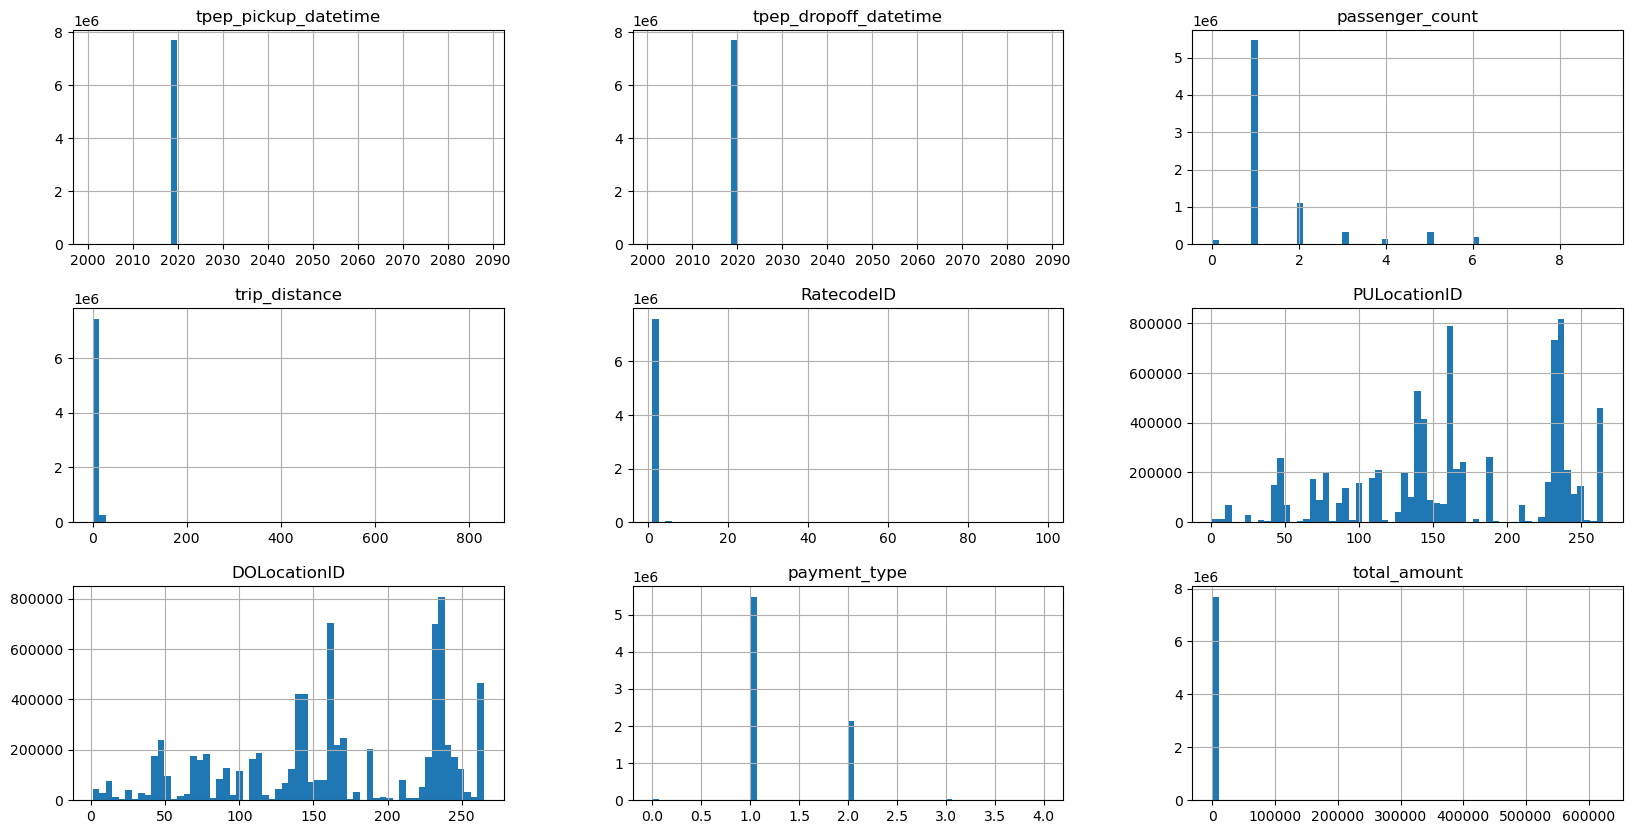

In [7]:
taxi_data.hist(figsize=(20, 10), bins=60)

In [8]:
taxi_data['RatecodeID'].value_counts()

RatecodeID
1.0     7430288
2.0      166093
5.0       54570
3.0       11801
4.0        4895
99.0        252
6.0          46
Name: count, dtype: int64

In [9]:
taxi_data['total_amount'].value_counts()

total_amount
7.30      170471
7.80      167914
6.80      167879
8.30      161705
8.80      159067
           ...  
196.32         1
0.56           1
167.11         1
302.30         1
76.89          1
Name: count, Length: 12193, dtype: int64

<Axes: xlabel='index', ylabel='total_amount'>

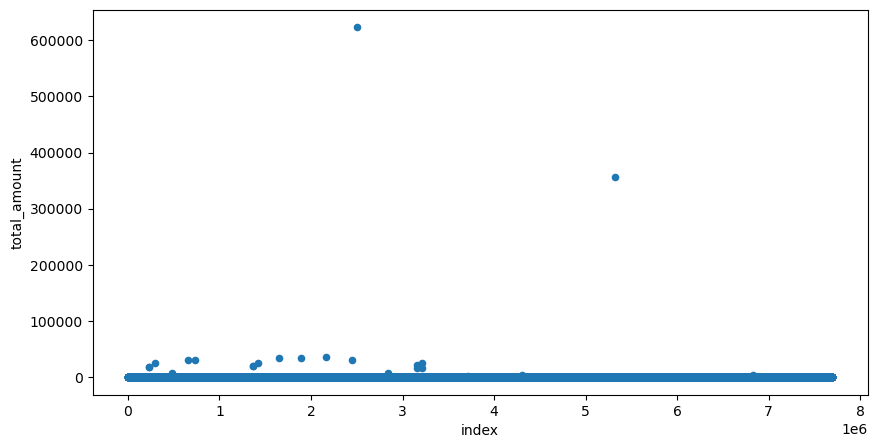

In [10]:
taxi_data.reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10, 5))

<Axes: xlabel='index', ylabel='total_amount'>

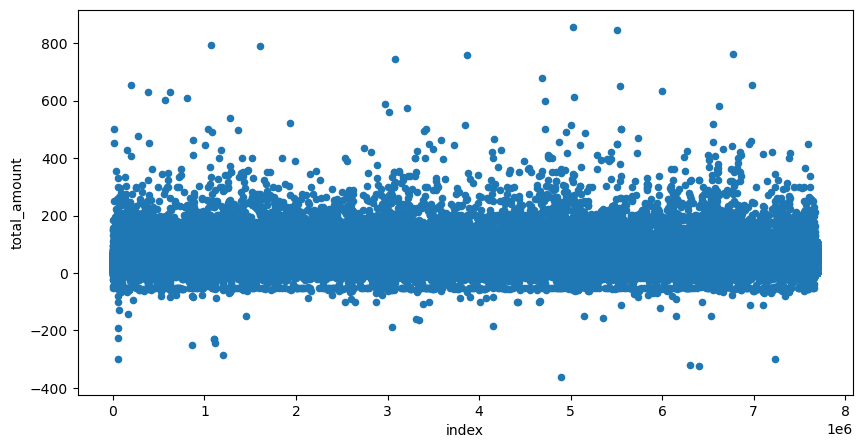

In [11]:
taxi_data[taxi_data['total_amount'] < 1000].reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10, 5))

(7127, 9)


<Axes: xlabel='index', ylabel='total_amount'>

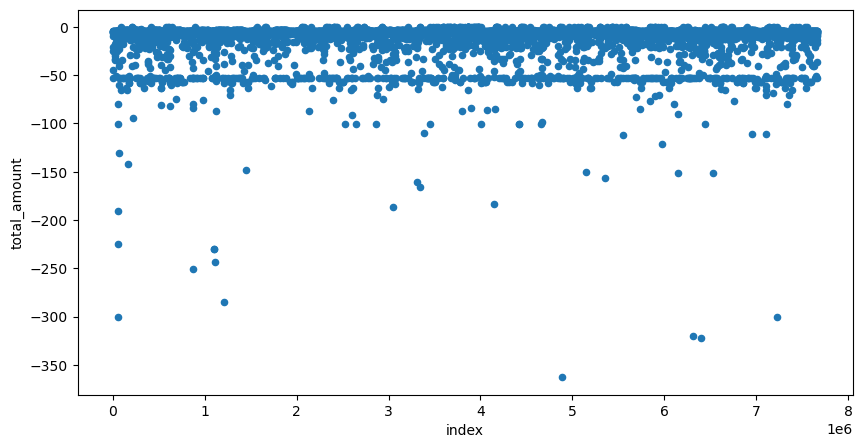

In [12]:
print(taxi_data[taxi_data['total_amount']<0].shape)
taxi_data[taxi_data['total_amount']<0].reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10, 5))

In [13]:
taxi_data[taxi_data['total_amount']<0].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
663,2019-01-01 00:32:56,2019-01-01 00:33:35,2.0,0.10,1.0,148,148,3,-3.8
2402,2019-01-01 00:14:18,2019-01-01 00:40:55,1.0,4.13,1.0,170,238,4,-20.3
2541,2019-01-01 00:31:27,2019-01-01 00:42:39,1.0,1.35,1.0,162,234,4,-9.8
2544,2019-01-01 00:45:57,2019-01-01 00:46:07,1.0,0.00,1.0,234,234,4,-3.8
2547,2019-01-01 00:48:35,2019-01-01 00:49:59,1.0,0.16,1.0,234,234,4,-4.3


In [14]:
taxi_data[taxi_data['total_amount']<0]['payment_type'].value_counts()

payment_type
3    4083
4    2667
2     376
1       1
Name: count, dtype: int64

<Axes: >

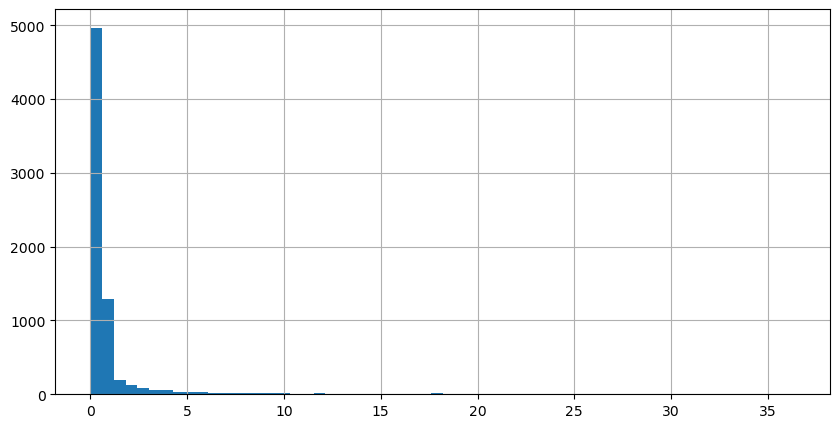

In [15]:
taxi_data[taxi_data['total_amount']<0]['trip_distance'].hist(bins=60, figsize=(10, 5))

<Axes: xlabel='index', ylabel='total_amount'>

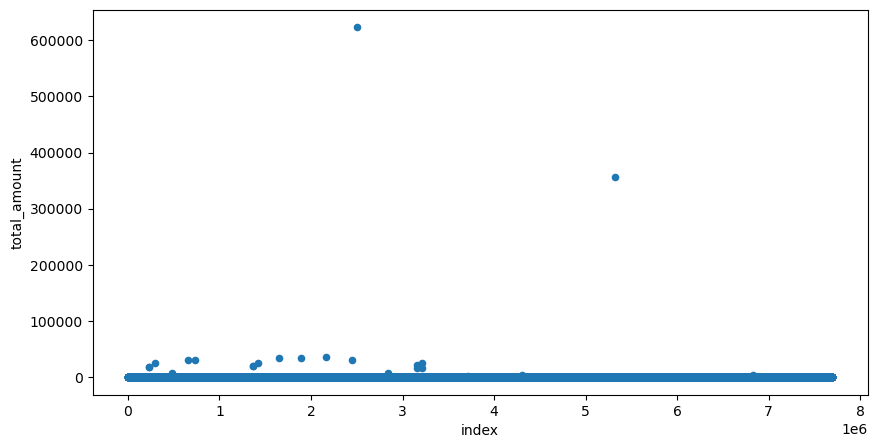

In [16]:
taxi_data.reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10, 5))

In [17]:
taxi_data[taxi_data['total_amount']>200].shape

(1166, 9)

In [18]:
taxi_data['total_amount'].mean()

np.float64(15.810651344610237)

# 3. Data cleaning <a id='data_cleaning'></a>  
[Back to top](#table_of_contents)

In [19]:
taxi_data_filtered = taxi_data[(taxi_data['total_amount']>=0)&(taxi_data['total_amount']<200)]

In [20]:
print(taxi_data.shape)
taxi_data_filtered.shape

(7696617, 9)


(7688319, 9)

In [21]:
taxi_data_filtered.isna().sum()

tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          28672
trip_distance                0
RatecodeID               28672
PULocationID                 0
DOLocationID                 0
payment_type                 0
total_amount                 0
dtype: int64

# 4. Data preparation <a id='data_preparation'></a>  
[Back to top](#table_of_contents)

In [22]:
taxi_data_filtered = taxi_data_filtered.dropna(subset=['passenger_count', 'RatecodeID', 'PULocationID', 'DOLocationID', 'payment_type'])

In [23]:
taxi_data_filtered['passenger_count'].value_counts()

passenger_count
1.0    5450602
2.0    1112657
5.0     323448
3.0     314333
6.0     200615
4.0     140626
0.0     117310
8.0         29
7.0         18
9.0          9
Name: count, dtype: int64

In [24]:
taxi_data_filtered['RatecodeID'].value_counts()

RatecodeID
1.0     7423946
2.0      165679
5.0       53249
3.0       11731
4.0        4769
99.0        233
6.0          40
Name: count, dtype: int64

In [25]:
taxi_data_filtered = taxi_data_filtered[taxi_data_filtered['RatecodeID'] != 99]

In [26]:
taxi_data_filtered['pickup_datetime'] = pd.to_datetime(taxi_data_filtered['tpep_pickup_datetime'])
taxi_data_filtered['dropoff_datetime'] = pd.to_datetime(taxi_data_filtered['tpep_dropoff_datetime'])
taxi_data_filtered['trip_duration_minutes'] = (taxi_data_filtered['dropoff_datetime'] - taxi_data_filtered['pickup_datetime']).dt.total_seconds() / 60
taxi_data_filtered['trip_duration_minutes'].describe()

count    7.659414e+06
mean     1.648240e+01
std      8.177233e+01
min     -8.428050e+04
25%      6.100000e+00
50%      1.016667e+01
75%      1.656667e+01
max      4.364802e+04
Name: trip_duration_minutes, dtype: float64

In [27]:
taxi_data_filtered = taxi_data_filtered[
    (taxi_data_filtered['trip_duration_minutes'] >= 1) & 
    (taxi_data_filtered['trip_duration_minutes'] <= 120)
]
taxi_data_filtered['trip_duration_minutes'].describe()

count    7.566974e+06
mean     1.293651e+01
std      9.888393e+00
min      1.000000e+00
25%      6.200000e+00
50%      1.021667e+01
75%      1.656667e+01
max      1.199667e+02
Name: trip_duration_minutes, dtype: float64

In [28]:
taxi_data_filtered = taxi_data_filtered[
    (taxi_data_filtered['trip_distance'] > 0.1) & 
    (taxi_data_filtered['trip_distance'] <= 30)
]
taxi_data_filtered['trip_distance'].describe()

count    7.544609e+06
mean     2.813872e+00
std      3.636594e+00
min      1.100000e-01
25%      9.300000e-01
50%      1.550000e+00
75%      2.830000e+00
max      3.000000e+01
Name: trip_distance, dtype: float64

In [29]:
taxi_data_filtered = taxi_data_filtered[
    (taxi_data_filtered['total_amount'] > 0) & 
    (taxi_data_filtered['total_amount'] <= 200)
]
taxi_data_filtered['total_amount'].describe()

count    7.544495e+06
mean     1.537005e+01
std      1.285719e+01
min      3.000000e-01
25%      8.300000e+00
50%      1.130000e+01
75%      1.656000e+01
max      1.998600e+02
Name: total_amount, dtype: float64

In [30]:
taxi_data_filtered.isna().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
total_amount             0
pickup_datetime          0
dropoff_datetime         0
trip_duration_minutes    0
dtype: int64

In [31]:
taxi_data_prepared = taxi_data_filtered.copy()

In [32]:
taxi_data_prepared.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
total_amount                    float64
pickup_datetime          datetime64[us]
dropoff_datetime         datetime64[us]
trip_duration_minutes           float64
dtype: object

In [33]:
taxi_data_prepared['RatecodeID'] = taxi_data_prepared['RatecodeID'].astype('string')
taxi_data_prepared['PULocationID'] = taxi_data_prepared['PULocationID'].astype('string')
taxi_data_prepared['DOLocationID'] = taxi_data_prepared['DOLocationID'].astype('string')
taxi_data_prepared['payment_type'] = taxi_data_prepared['payment_type'].astype('string')


In [34]:
taxi_data_prepared.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID               string[python]
PULocationID             string[python]
DOLocationID             string[python]
payment_type             string[python]
total_amount                    float64
pickup_datetime          datetime64[us]
dropoff_datetime         datetime64[us]
trip_duration_minutes           float64
dtype: object

In [35]:
taxi_data_prepared.head()


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount,pickup_datetime,dropoff_datetime,trip_duration_minutes
0,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,151,239,1,9.95,2019-01-01 00:46:40,2019-01-01 00:53:20,6.666667
1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,239,246,1,16.30,2019-01-01 00:59:47,2019-01-01 01:18:59,19.200000
7,2019-01-01 00:21:28,2019-01-01 00:28:37,1.0,1.3,1.0,163,229,1,9.05,2019-01-01 00:21:28,2019-01-01 00:28:37,7.150000
8,2019-01-01 00:32:01,2019-01-01 00:45:39,1.0,3.7,1.0,229,7,1,18.50,2019-01-01 00:32:01,2019-01-01 00:45:39,13.633333
9,2019-01-01 00:57:32,2019-01-01 01:09:32,2.0,2.1,1.0,141,234,1,13.00,2019-01-01 00:57:32,2019-01-01 01:09:32,12.000000


In [36]:
taxi_data_prepared['transaction_date'] = taxi_data_prepared['pickup_datetime'].dt.date
taxi_data_prepared['transaction_year'] = taxi_data_prepared['pickup_datetime'].dt.year
taxi_data_prepared['transaction_month'] = taxi_data_prepared['pickup_datetime'].dt.month
taxi_data_prepared['transaction_day'] = taxi_data_prepared['pickup_datetime'].dt.day
taxi_data_prepared['transaction_hour'] = taxi_data_prepared['pickup_datetime'].dt.hour

taxi_data_prepared['transaction_weekday'] = taxi_data_prepared['pickup_datetime'].dt.weekday
taxi_data_prepared['weekend'] = taxi_data_prepared['transaction_weekday'].isin([5, 6])

taxi_data_prepared.head()
taxi_data_prepared['passenger_count'] = taxi_data_prepared['passenger_count'].astype('int')

In [37]:
taxi_data_prepared.head()
taxi_data_prepared.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'total_amount', 'pickup_datetime', 'dropoff_datetime',
       'trip_duration_minutes', 'transaction_date', 'transaction_year',
       'transaction_month', 'transaction_day', 'transaction_hour',
       'transaction_weekday', 'weekend'],
      dtype='object')

In [38]:
taxi_data_prepared['passenger_count'] = taxi_data_prepared['passenger_count'].astype('int')
taxi_data_prepared['transaction_year'] = taxi_data_prepared['transaction_year'].astype('int')
taxi_data_prepared['transaction_month'] = taxi_data_prepared['transaction_month'].astype('int')


array([[<Axes: title={'center': 'tpep_pickup_datetime'}>,
        <Axes: title={'center': 'tpep_dropoff_datetime'}>,
        <Axes: title={'center': 'passenger_count'}>,
        <Axes: title={'center': 'trip_distance'}>],
       [<Axes: title={'center': 'total_amount'}>,
        <Axes: title={'center': 'pickup_datetime'}>,
        <Axes: title={'center': 'dropoff_datetime'}>,
        <Axes: title={'center': 'trip_duration_minutes'}>],
       [<Axes: title={'center': 'transaction_year'}>,
        <Axes: title={'center': 'transaction_month'}>,
        <Axes: title={'center': 'transaction_day'}>,
        <Axes: title={'center': 'transaction_hour'}>],
       [<Axes: title={'center': 'transaction_weekday'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

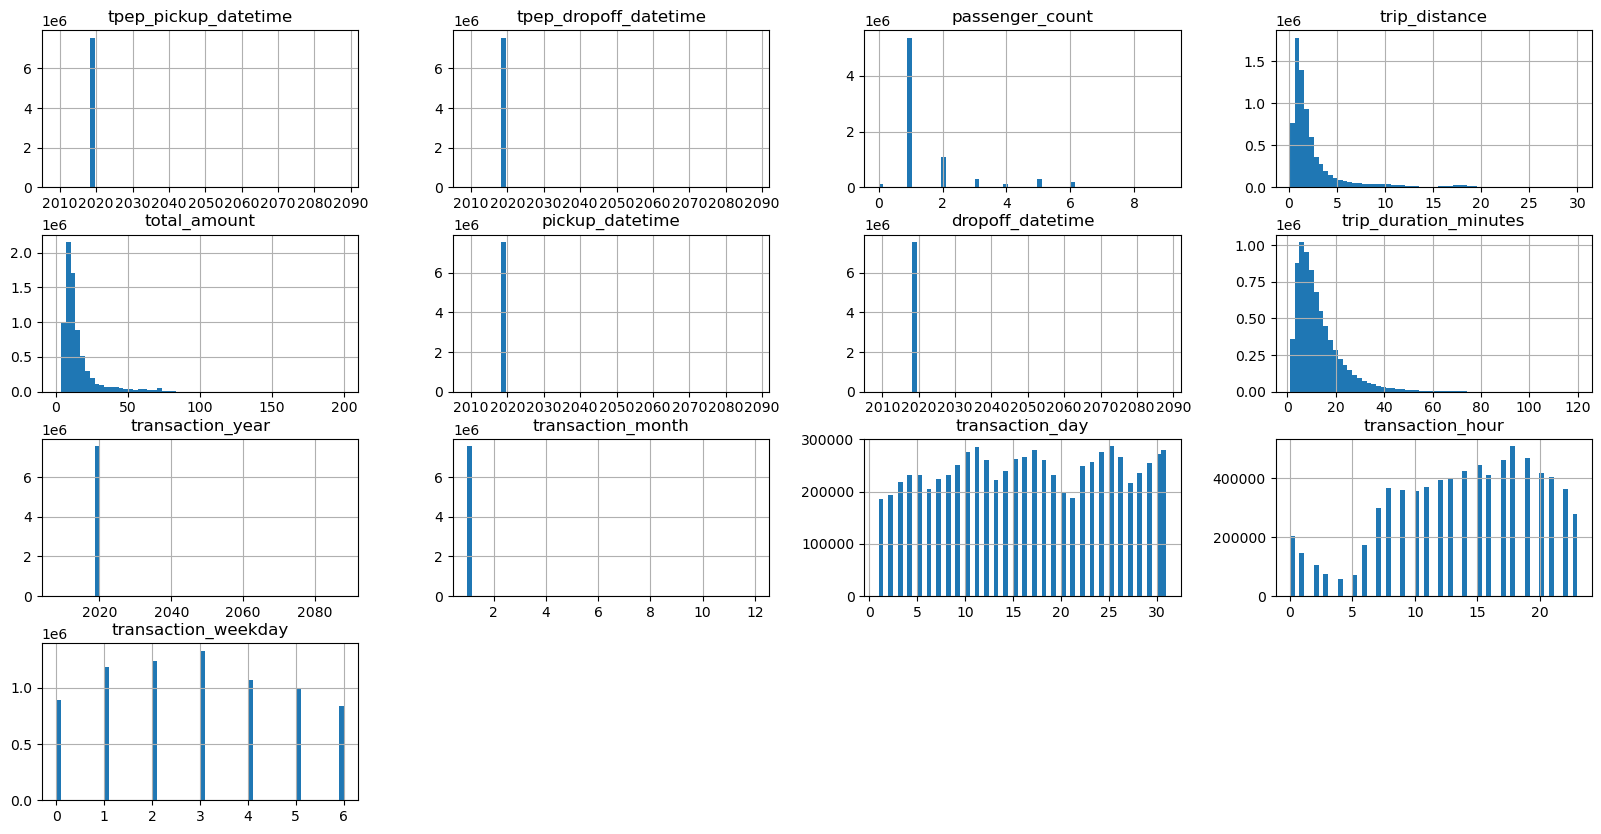

In [39]:
taxi_data_prepared.hist(figsize=(20, 10), bins=60)

In [40]:
taxi_data_prepared = taxi_data_prepared[taxi_data_prepared['transaction_year'] == 2019]
taxi_data_prepared = taxi_data_prepared[taxi_data_prepared['transaction_month'] == 1]

In [41]:
categorical_columns = ['PULocationID', 'transaction_year', 'transaction_month', 
                      'transaction_day', 'transaction_hour', 'transaction_weekday', 
                      'transaction_date']

numerical_columns = ['trip_distance', 'total_amount']
all_needed_columns = categorical_columns + numerical_columns

In [42]:
main_taxi_df = taxi_data_prepared[all_needed_columns]
print(main_taxi_df.shape)
main_taxi_df.head()

(7544066, 9)


,PULocationID,transaction_year,transaction_month,transaction_day,transaction_hour,transaction_weekday,transaction_date,trip_distance,total_amount
0,151,2019,1,1,0,1,2019-01-01,1.5,9.95
1,239,2019,1,1,0,1,2019-01-01,2.6,16.30
7,163,2019,1,1,0,1,2019-01-01,1.3,9.05
8,229,2019,1,1,0,1,2019-01-01,3.7,18.50
9,141,2019,1,1,0,1,2019-01-01,2.1,13.00


In [43]:
taxi_grouped_by_region = main_taxi_df.groupby(categorical_columns).mean().reset_index()
taxi_grouped_by_region['count_of_transactions'] = main_taxi_df.groupby(categorical_columns).count().reset_index()['total_amount']
print(taxi_grouped_by_region.shape)
taxi_grouped_by_region.head()

(99946, 10)


,PULocationID,transaction_year,transaction_month,transaction_day,transaction_hour,transaction_weekday,transaction_date,trip_distance,total_amount,count_of_transactions
0,1,2019,1,1,10,1,2019-01-01,16.900,16.56,1
1,1,2019,1,2,2,2,2019-01-02,1.270,30.30,1
2,1,2019,1,2,13,2,2019-01-02,18.215,41.85,2
3,1,2019,1,2,14,2,2019-01-02,7.920,25.30,1
4,1,2019,1,2,18,2,2019-01-02,3.100,120.35,1


<Axes: >

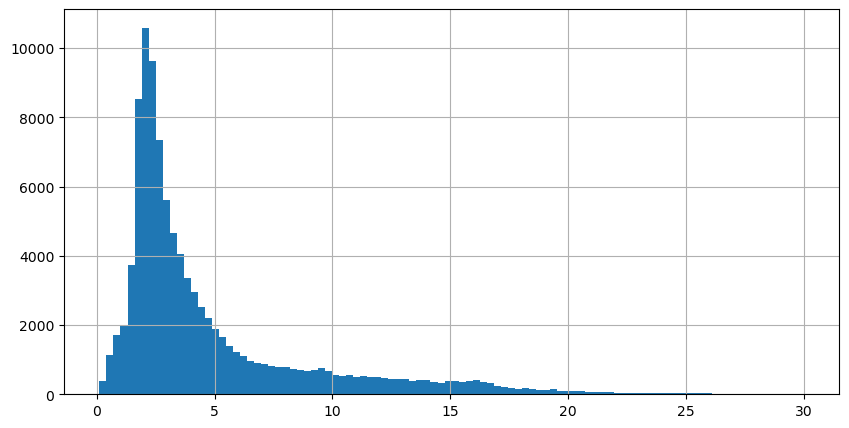

In [44]:
taxi_grouped_by_region['trip_distance'].hist(bins=100, figsize=(10, 5))

<Axes: >

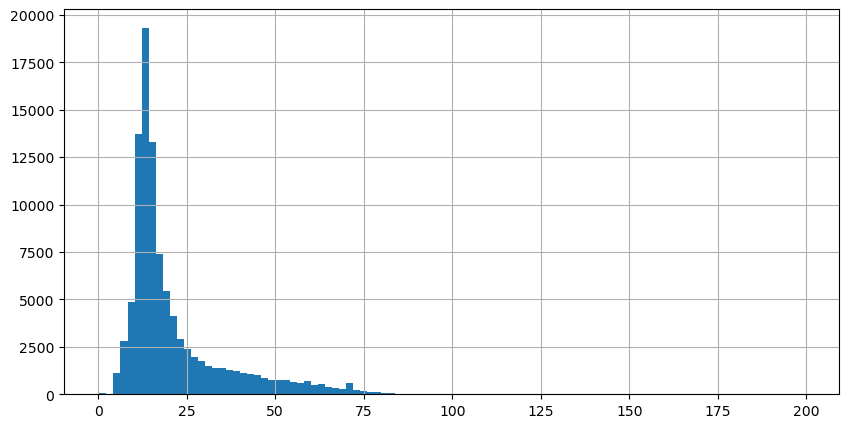

In [45]:
taxi_grouped_by_region['total_amount'].hist(bins=100, figsize=(10, 5))

# 5. Benchmark model <a id='benchmark_model'></a>  
[Back to top](#table_of_contents)

In [46]:
data_for_benchmark_model = taxi_grouped_by_region.copy()

In [47]:
categorical_features_benchmark = ['PULocationID', 'transaction_month', 'transaction_day', 'transaction_hour']
input_features_benchmark = categorical_features_benchmark + ['trip_distance']
target_feature_benchmark = 'total_amount'

# 5.1. Train-test split <a id='train_test_split'></a>  
[Back to top](#table_of_contents)

In [48]:
from sklearn.model_selection import train_test_split

X_bench = data_for_benchmark_model[input_features_benchmark]
y_bench = data_for_benchmark_model[target_feature_benchmark]

X_bench = pd.get_dummies(X_bench)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bench, y_bench, test_size=0.33, random_state=42)

# 5.2. Fit a model to the data <a id='fit_model'></a>  
[Back to top](#table_of_contents)

In [49]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X_train_b, y_train_b)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


# 5.3. Model evaluation <a id='model_evaluation'></a>  
[Back to top](#table_of_contents)

In [50]:
model_at_hand = tree

y_pred_b = model_at_hand.predict(X_test_b)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test_b, y_pred_b))
print('mean_squared_error', mean_squared_error(y_test_b, y_pred_b))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test_b, y_pred_b)))
print('r2_score', r2_score(y_test_b, y_pred_b))

mean_absolute_error 2.7498422741790254
mean_squared_error 43.853285775644736
root_mean_squared_error 6.622181345723231
r2_score 0.8142103047285655


<Axes: xlabel='true', ylabel='predicted'>

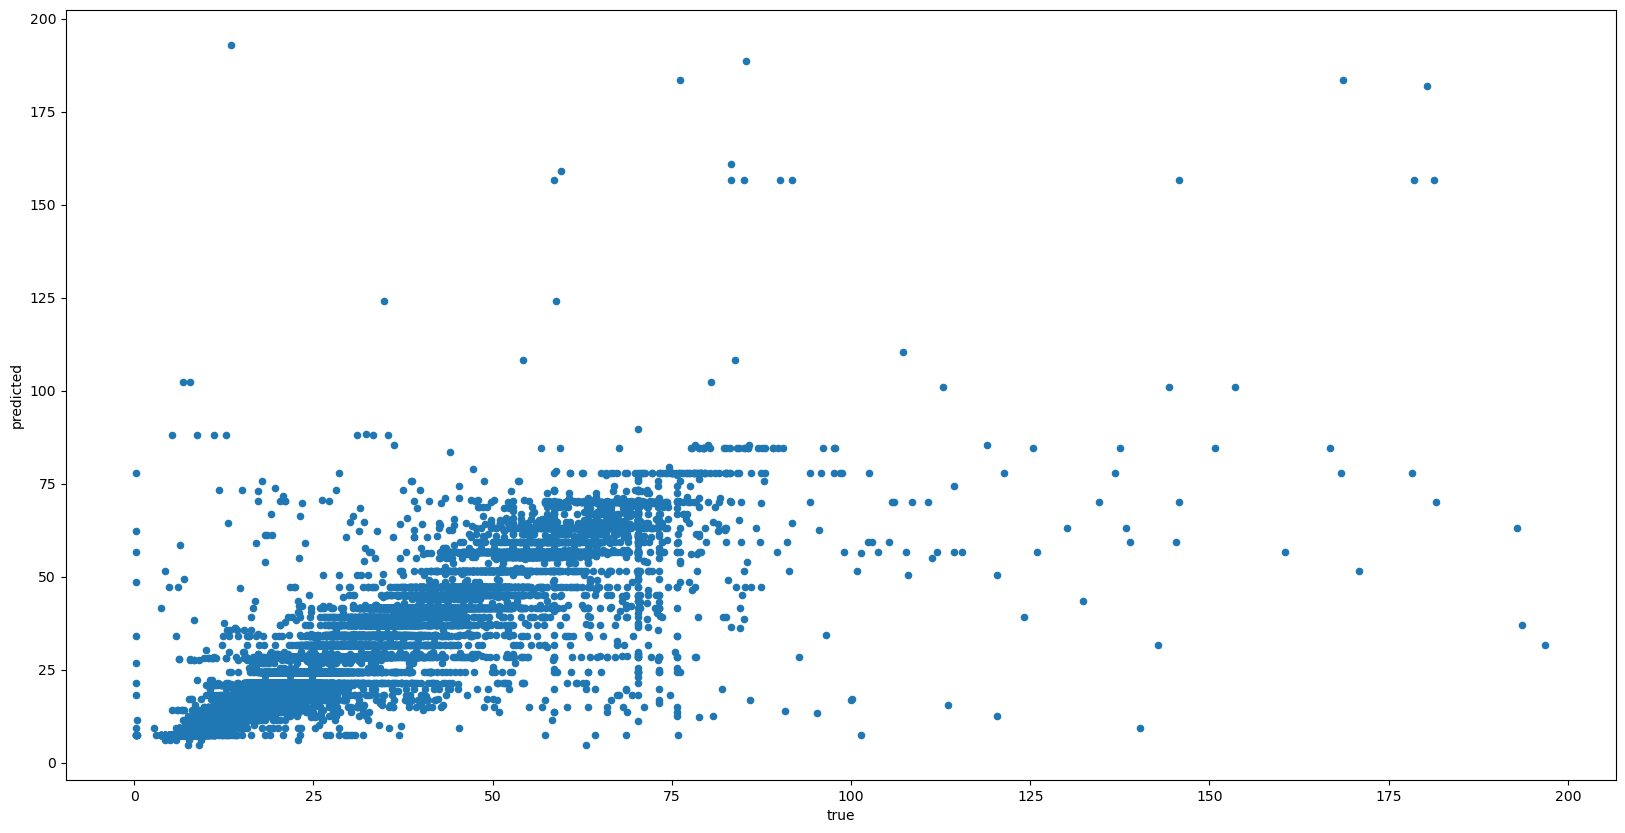

In [51]:
data = {'true': y_test_b, 'predicted': y_pred_b}
results = pd.DataFrame(data)

results.plot(figsize=(20, 10), kind='scatter', x='true', y='predicted')

# 5.4. Fix problems <a id='fix_problems'></a>  
[Back to top](#table_of_contents)

In [52]:
categorical_features_benchmark = ['PULocationID', 'transaction_month', 'transaction_day', 'transaction_hour']
input_features_benchmark = categorical_features_benchmark
target_feature_benchmark = 'total_amount'

from sklearn.model_selection import train_test_split

X_bench = data_for_benchmark_model[input_features_benchmark]
y_bench = data_for_benchmark_model[target_feature_benchmark]

X_bench = pd.get_dummies(X_bench)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bench, y_bench, test_size=0.33, random_state=42)

from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X_train_b, y_train_b)

model_at_hand = tree

y_pred_b = model_at_hand.predict(X_test_b)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test_b, y_pred_b))
print('mean_squared_error', mean_squared_error(y_test_b, y_pred_b))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test_b, y_pred_b)))
print('r2_score', r2_score(y_test_b, y_pred_b))

mean_absolute_error 9.341590295877497
mean_squared_error 192.61788579247974
root_mean_squared_error 13.878684584371811
r2_score 0.18395126676943607


<Axes: xlabel='true', ylabel='predicted'>

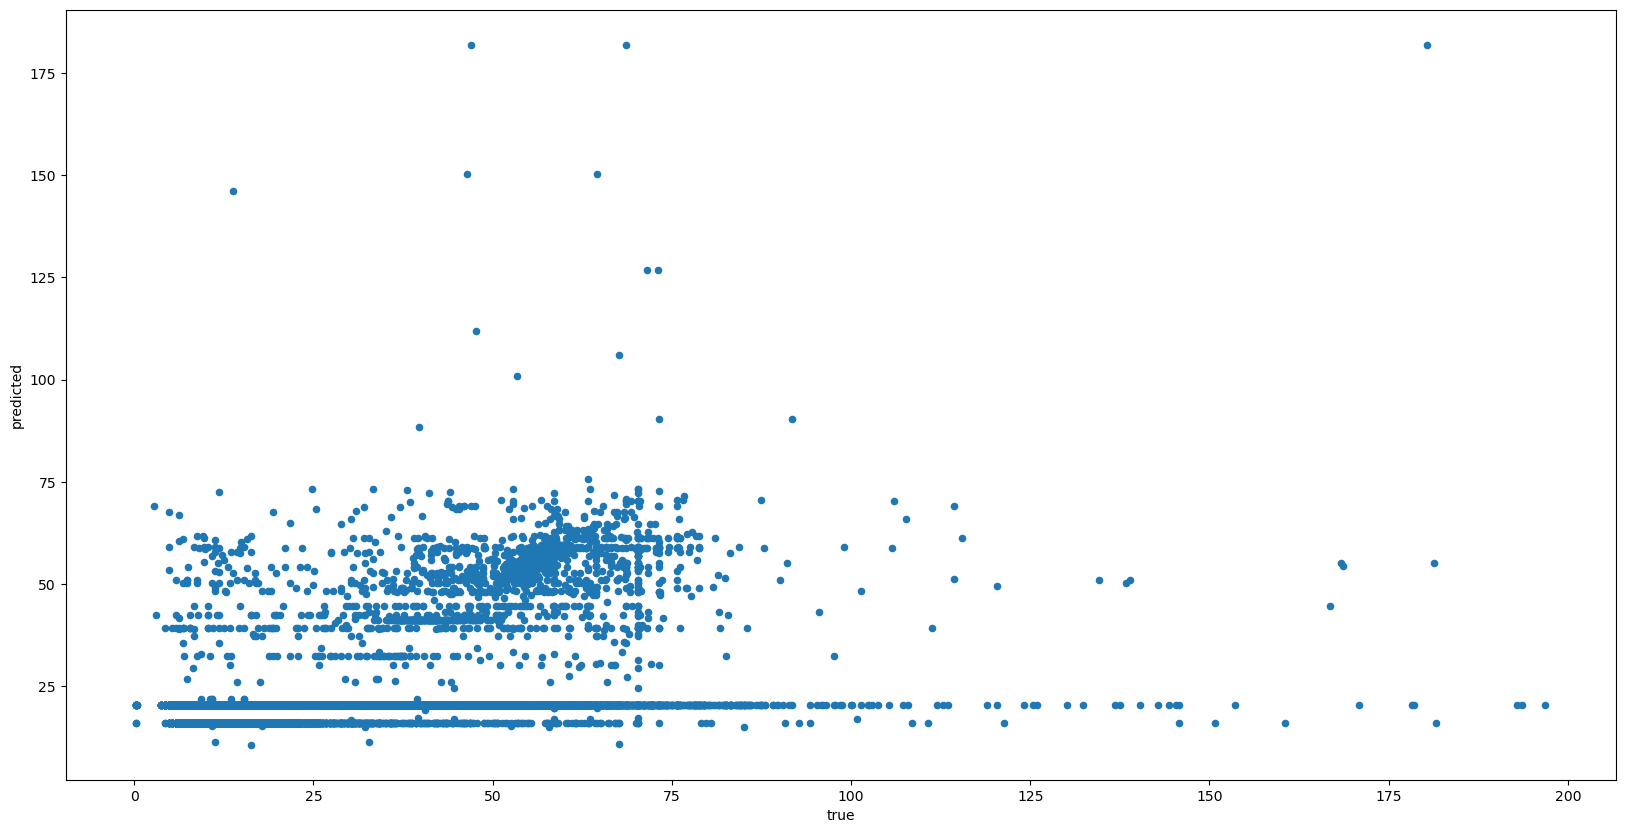

In [53]:
data = {'true': y_test_b, 'predicted': y_pred_b}
results = pd.DataFrame(data)

results.plot(figsize=(20, 10), kind='scatter', x='true', y='predicted')

# 6. Feature engineering <a id='feature_engineering'></a>  
[Back to top](#table_of_contents)

In [54]:
taxi_grouped_by_region.head()

,PULocationID,transaction_year,transaction_month,transaction_day,transaction_hour,transaction_weekday,transaction_date,trip_distance,total_amount,count_of_transactions
0,1,2019,1,1,10,1,2019-01-01,16.900,16.56,1
1,1,2019,1,2,2,2,2019-01-02,1.270,30.30,1
2,1,2019,1,2,13,2,2019-01-02,18.215,41.85,2
3,1,2019,1,2,14,2,2019-01-02,7.920,25.30,1
4,1,2019,1,2,18,2,2019-01-02,3.100,120.35,1


In [55]:
data_with_new_features = taxi_grouped_by_region.copy()

In [56]:
data_with_new_features = taxi_grouped_by_region.copy()
from pandas.tseries.holiday import USFederalHolidayCalendar

cal = USFederalHolidayCalendar()
holidays = cal.holidays(start='2018', end='2020').date

data_with_new_features['transaction_date'] = pd.to_datetime(data_with_new_features['transaction_date']).dt.date
data_with_new_features['is_holiday'] = data_with_new_features['transaction_date'].isin(holidays)

print("Holidays found:", data_with_new_features['is_holiday'].sum())


Holidays found: 6175


In [57]:
data_with_new_features.head()

,PULocationID,transaction_year,transaction_month,transaction_day,transaction_hour,transaction_weekday,transaction_date,trip_distance,total_amount,count_of_transactions,is_holiday
0,1,2019,1,1,10,1,2019-01-01,16.900,16.56,1,True
1,1,2019,1,2,2,2,2019-01-02,1.270,30.30,1,False
2,1,2019,1,2,13,2,2019-01-02,18.215,41.85,2,False
3,1,2019,1,2,14,2,2019-01-02,7.920,25.30,1,False
4,1,2019,1,2,18,2,2019-01-02,3.100,120.35,1,False


In [58]:
zone_lookup = pd.read_csv('data/taxi_zone_lookup.csv')
zone_lookup = zone_lookup[['LocationID', 'Borough']]
zone_lookup['LocationID'] = zone_lookup['LocationID'].astype('string')
zone_lookup.head()

,LocationID,Borough
0,1,EWR
1,2,Queens
2,3,Bronx
3,4,Manhattan
4,5,Staten Island


In [59]:
data_with_new_features = data_with_new_features.merge(zone_lookup, left_on='PULocationID', right_on='LocationID', how='left')
data_with_new_features.head()

,PULocationID,transaction_year,transaction_month,transaction_day,transaction_hour,transaction_weekday,transaction_date,trip_distance,total_amount,count_of_transactions,is_holiday,LocationID,Borough
0,1,2019,1,1,10,1,2019-01-01,16.900,16.56,1,True,1,EWR
1,1,2019,1,2,2,2,2019-01-02,1.270,30.30,1,False,1,EWR
2,1,2019,1,2,13,2,2019-01-02,18.215,41.85,2,False,1,EWR
3,1,2019,1,2,14,2,2019-01-02,7.920,25.30,1,False,1,EWR
4,1,2019,1,2,18,2,2019-01-02,3.100,120.35,1,False,1,EWR


In [60]:
data_with_new_features['Borough'].value_counts().rename('Borough')

Borough
Manhattan        45219
Brooklyn         22891
Queens           21124
Bronx             9137
Unknown            744
Staten Island      221
EWR                 36
Name: Borough, dtype: int64

In [61]:
nyc_weather = pd.read_csv('data/nyc_weather.csv')
nyc_weather.head()

,date and time,temperature,humidity,wind speed,cloud cover,amount of precipitation31.12.2019 22:00,6.1,65,6,100%.,...,23.3.14,82.10,3.166,20-30%..172,Trace of precipitation02.09.2019 23:00,23.3.15,85.9,3.167,50%..132,Unnamed: 4800
0,02.09.2019 20:00,23.9,82,4,70 - 80%.,2.002.09.2019 17:00,25.0,79,4,70 - 80%.,...,9.4,93.0,5.0,100%.,8.005.05.2019 23:00,9.4,100.0,6.0,100%.,7.0
1,7.005.05.2019 20:00,10.0,96,8,100%.,5.005.05.2019 17:00,10.0,93,9,100%.,...,-3.3,51.0,4.0,70 - 80%.,07.01.2019 06:00,-3.3,51.0,4.0,70 - 80%.,NaN
2,07.01.2019 04:00,-1.7,43,6,no clouds,07.01.2019 03:00,-1.7,43,6,no clouds,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
nyc_weather = pd.read_csv('data/nyc_weather_clean.csv')
nyc_weather.head()

,date and time,temperature,humidity,wind speed,cloud cover,amount of precipitation
0,31.12.2019 22:00,6.1,65.0,6.0,100%.,0.3
1,31.12.2019 19:00,6.7,71.0,5.0,70 - 80%.,NaN
2,...,NaN,NaN,NaN,NaN,NaN
3,01.01.2019 01:00,8.3,97.0,0.0,100%.,29.0


In [63]:
nyc_weather.shape

(4, 6)

In [64]:
nyc_weather.dtypes

date and time               object
temperature                float64
humidity                   float64
wind speed                 float64
cloud cover                 object
amount of precipitation    float64
dtype: object

In [65]:
nyc_weather['cloud cover'].value_counts()

cloud cover
100%.        2
70 - 80%.    1
Name: count, dtype: int64

In [66]:
nyc_weather.isna().sum()

date and time              0
temperature                1
humidity                   1
wind speed                 1
cloud cover                1
amount of precipitation    2
dtype: int64

In [67]:
nyc_weather.columns

Index(['date and time', 'temperature', 'humidity', 'wind speed', 'cloud cover',
       'amount of precipitation'],
      dtype='object')

In [68]:
import pandas as pd
from io import StringIO
import re

raw_text = """date and time,temperature,humidity,wind speed,cloud cover,amount of precipitation
31.12.2019 22:00,6.1,65,6,100%.,0.3
31.12.2019 19:00,6.7,71,5,70 â€“ 80%.,
...
01.01.2019 01:00,8.3,97,0,100%.,29.0
"""

# Fix encoding artifacts like “â€“”
clean_text = (raw_text
              .replace("â€“", "-")
              .replace("Â", ""))  # in case there are stray Â chars

# Load to DataFrame
df = pd.read_csv(StringIO(clean_text))

df.head(), df.shape

df.to_csv("nyc_weather_clean.csv", index=False)


In [69]:
df.columns

Index(['date and time', 'temperature', 'humidity', 'wind speed', 'cloud cover',
       'amount of precipitation'],
      dtype='object')

In [70]:
nyc_weather['amount of precipitation'] = nyc_weather['amount of precipitation'].replace('Trace of precipitation', 0.1)
nyc_weather['amount of precipitation'] = nyc_weather['amount of precipitation'].astype(float)

nyc_weather['amount of precipitation'].interpolate(inplace=True)

/var/folders/43/8jl10vhs7kx3q30bcy_yj3j40000gn/T/ipykernel_3491/2393814714.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  nyc_weather['amount of precipitation'].interpolate(inplace=True)


In [71]:
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('70 - 80%.', 0.7)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('100%.', 1)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('20 - 30%.', 0.3)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('50%.', 0.5)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('no clouds', 0)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('Sky obscured by fog and/or other meteorological phenomena.', 1)
nyc_weather['cloud cover'] = nyc_weather['cloud cover'].astype(float)
nyc_weather['cloud cover'].interpolate(inplace=True)

/var/folders/43/8jl10vhs7kx3q30bcy_yj3j40000gn/T/ipykernel_3491/1023717494.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  nyc_weather['cloud cover'] = nyc_weather['cloud cover'].replace('100%.', 1)
/var/folders/43/8jl10vhs7kx3q30bcy_yj3j40000gn/T/ipykernel_3491/1023717494.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplac

In [72]:
cloud_map = {
    '70 - 80%.': 0.7,
    '100%.': 1.0,
    '20 - 30%.': 0.3,
    '50%.': 0.5,
    'no clouds': 0.0,
    'Sky obscured by fog and/or other meteorological phenomena.': 1.0,
}

nyc_weather['cloud cover'] = (
    nyc_weather['cloud cover']
    .replace(cloud_map)
    .infer_objects(copy=False)
    .astype(float)
    .interpolate()
)


In [73]:
cloud_map = {
    '70 - 80%.': 0.7,
    '100%.': 1.0,
    '20 - 30%.': 0.3,
    '50%.': 0.5,
    'no clouds': 0.0,
    'Sky obscured by fog and/or other meteorological phenomena.': 1.0,
}

nyc_weather['cloud cover'] = (
    nyc_weather['cloud cover']
    .replace(cloud_map)
    .infer_objects(copy=False)
)


In [74]:
nyc_weather.dtypes

date and time               object
temperature                float64
humidity                   float64
wind speed                 float64
cloud cover                float64
amount of precipitation    float64
dtype: object

In [1]:
mask_bad = nyc_weather['date and time'].str.contains(r"\.\.\.", na=False)
print("Bad rows:", mask_bad.sum())
nyc_weather = nyc_weather[~mask_bad]

nyc_weather['date and time'] = pd.to_datetime(
    nyc_weather['date and time'],
    format="%d.%m.%Y %H:%M",
    errors="coerce"
)

nyc_weather = nyc_weather.dropna(subset=['date and time'])

nyc_weather['hour'] = nyc_weather['date and time'].dt.hour
nyc_weather['day'] = nyc_weather['date and time'].dt.day
nyc_weather['month'] = nyc_weather['date and time'].dt.month

NameError: name 'nyc_weather' is not defined

In [78]:
bad_dates = nyc_weather[nyc_weather['date and time'].isna()]
print(bad_dates['date and time'].head())

Series([], Name: date and time, dtype: datetime64[ns])


In [80]:
nyc_weather.loc[:, 'date and time'] = pd.to_datetime(nyc_weather.loc[:, 'date and time'])
nyc_weather['hour'] = nyc_weather['date and time'].dt.hour
nyc_weather['day'] = nyc_weather['date and time'].dt.day
nyc_weather['month'] = nyc_weather['date and time'].dt.month

In [ ]:
nyc_weather['date and time'] = pd.to_datetime(
    nyc_weather['date and time'],
    format="%d.%m.%Y %H:%M",
    errors="coerce"
)

bad = nyc_weather[nyc_weather['date and time'].isna()]
print(bad.head())
print(bad.shape)

Empty DataFrame
Columns: [date and time, temperature, humidity, wind speed, cloud cover, amount of precipitation, hour, day, month]
Index: []
(0, 9)


In [82]:
nyc_weather = nyc_weather.dropna(subset=['date and time'])

In [83]:
nyc_weather.head()

,date and time,temperature,humidity,wind speed,cloud cover,amount of precipitation,hour,day,month
0,2019-12-31 22:00:00,6.1,65.0,6.0,1.0,0.300000,22,31,12
1,2019-12-31 19:00:00,6.7,71.0,5.0,0.7,9.866667,19,31,12
3,2019-01-01 01:00:00,8.3,97.0,0.0,1.0,29.000000,1,1,1


In [84]:
data_with_new_features.head()

,PULocationID,transaction_year,transaction_month,transaction_day,transaction_hour,transaction_weekday,transaction_date,trip_distance,total_amount,count_of_transactions,is_holiday,LocationID,Borough
0,1,2019,1,1,10,1,2019-01-01,16.900,16.56,1,True,1,EWR
1,1,2019,1,2,2,2,2019-01-02,1.270,30.30,1,False,1,EWR
2,1,2019,1,2,13,2,2019-01-02,18.215,41.85,2,False,1,EWR
3,1,2019,1,2,14,2,2019-01-02,7.920,25.30,1,False,1,EWR
4,1,2019,1,2,18,2,2019-01-02,3.100,120.35,1,False,1,EWR


In [85]:
nyc_taxi_with_weather = data_with_new_features.merge(nyc_weather, left_on = ['transaction_month', 'transaction_day', 'transaction_hour'], right_on = ['month', 'day', 'hour'], how='left')

print(nyc_taxi_with_weather.shape)
nyc_taxi_with_weather.head()

(99946, 22)


,PULocationID,transaction_year,transaction_month,transaction_day,transaction_hour,transaction_weekday,transaction_date,trip_distance,total_amount,count_of_transactions,...,Borough,date and time,temperature,humidity,wind speed,cloud cover,amount of precipitation,hour,day,month
0,1,2019,1,1,10,1,2019-01-01,16.900,16.56,1,...,EWR,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2019,1,2,2,2,2019-01-02,1.270,30.30,1,...,EWR,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2019,1,2,13,2,2019-01-02,18.215,41.85,2,...,EWR,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2019,1,2,14,2,2019-01-02,7.920,25.30,1,...,EWR,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2019,1,2,18,2,2019-01-02,3.100,120.35,1,...,EWR,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
nyc_taxi_with_weather = nyc_taxi_with_weather.drop(['date and time', 'hour', 'month', 'day'], axis=1)

In [87]:
nyc_taxi_with_weather.head()

,PULocationID,transaction_year,transaction_month,transaction_day,transaction_hour,transaction_weekday,transaction_date,trip_distance,total_amount,count_of_transactions,is_holiday,LocationID,Borough,temperature,humidity,wind speed,cloud cover,amount of precipitation
0,1,2019,1,1,10,1,2019-01-01,16.900,16.56,1,True,1,EWR,NaN,NaN,NaN,NaN,NaN
1,1,2019,1,2,2,2,2019-01-02,1.270,30.30,1,False,1,EWR,NaN,NaN,NaN,NaN,NaN
2,1,2019,1,2,13,2,2019-01-02,18.215,41.85,2,False,1,EWR,NaN,NaN,NaN,NaN,NaN
3,1,2019,1,2,14,2,2019-01-02,7.920,25.30,1,False,1,EWR,NaN,NaN,NaN,NaN,NaN
4,1,2019,1,2,18,2,2019-01-02,3.100,120.35,1,False,1,EWR,NaN,NaN,NaN,NaN,NaN


In [88]:
nyc_taxi_with_weather.isna().sum()

PULocationID                   0
transaction_year               0
transaction_month              0
transaction_day                0
transaction_hour               0
transaction_weekday            0
transaction_date               0
trip_distance                  0
total_amount                   0
count_of_transactions          0
is_holiday                     0
LocationID                     0
Borough                      574
temperature                99778
humidity                   99778
wind speed                 99778
cloud cover                99778
amount of precipitation    99778
dtype: int64

In [89]:
nyc_taxi_with_weather = nyc_taxi_with_weather.sort_values(['transaction_date', 'transaction_hour']).reset_index().drop('index', axis=1)

In [90]:
# nyc_taxi_with_weather = nyc_taxi_with_weather.interpolate()
# nyc_taxi_with_weather = nyc_taxi_with_weather.fillna(method='bfill')
# nyc_taxi_with_weather.isna().sum()

numeric_cols = nyc_taxi_with_weather.select_dtypes(include=['number']).columns

nyc_taxi_with_weather[numeric_cols] = (
    nyc_taxi_with_weather[numeric_cols].interpolate()
)

nyc_taxi_with_weather = nyc_taxi_with_weather.fillna(method='bfill')

nyc_taxi_with_weather.isna().sum()


/var/folders/43/8jl10vhs7kx3q30bcy_yj3j40000gn/T/ipykernel_3491/1935273603.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  nyc_taxi_with_weather = nyc_taxi_with_weather.fillna(method='bfill')


PULocationID               0
transaction_year           0
transaction_month          0
transaction_day            0
transaction_hour           0
transaction_weekday        0
transaction_date           0
trip_distance              0
total_amount               0
count_of_transactions      0
is_holiday                 0
LocationID                 0
Borough                    0
temperature                0
humidity                   0
wind speed                 0
cloud cover                0
amount of precipitation    0
dtype: int64

In [91]:
nyc_taxi_with_weather.head()

,PULocationID,transaction_year,transaction_month,transaction_day,transaction_hour,transaction_weekday,transaction_date,trip_distance,total_amount,count_of_transactions,is_holiday,LocationID,Borough,temperature,humidity,wind speed,cloud cover,amount of precipitation
0,10,2019,1,1,0,1,2019-01-01,3.020000,14.300000,2,True,10,Queens,8.3,97.0,0.0,1.0,29.0
1,100,2019,1,1,0,1,2019-01-01,2.801852,18.130000,54,True,100,Manhattan,8.3,97.0,0.0,1.0,29.0
2,106,2019,1,1,0,1,2019-01-01,2.593333,15.373333,3,True,106,Brooklyn,8.3,97.0,0.0,1.0,29.0
3,107,2019,1,1,0,1,2019-01-01,2.381655,14.716326,411,True,107,Manhattan,8.3,97.0,0.0,1.0,29.0
4,11,2019,1,1,0,1,2019-01-01,1.795000,9.300000,2,True,11,Brooklyn,8.3,97.0,0.0,1.0,29.0


# 7. Model training <a id='model_training'></a>  
[Back to top](#table_of_contents)

In [92]:
data_for_model = nyc_taxi_with_weather.copy()

In [93]:
categorical_features = ['PULocationID', 'transaction_month', 'transaction_day', 'transaction_hour', 'transaction_weekday', 'is_holiday', 'Borough']

input_features = categorical_features + ['temperature', 'humidity', 'wind speed', 'cloud cover', 'amount of precipitation']

target_feature = 'total_amount'

# train-test split

In [94]:
from sklearn.model_selection import train_test_split

X = data_for_model[input_features]
y = data_for_model[target_feature]

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# 7.1. Decision tree <a id='decision_tree'></a>  
[Back to top](#table_of_contents)

In [95]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = DecisionTreeRegressor(max_depth=10)
decision_tree.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [96]:
model_at_hand = decision_tree

y_pred = model_at_hand.predict(X_test)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2_score', r2_score(y_test, y_pred))

mean_absolute_error 7.715667060486585
mean_squared_error 160.5102768194443
root_mean_squared_error 12.669265046538584
r2_score 0.31895545651044177


<Axes: xlabel='true', ylabel='predicted'>

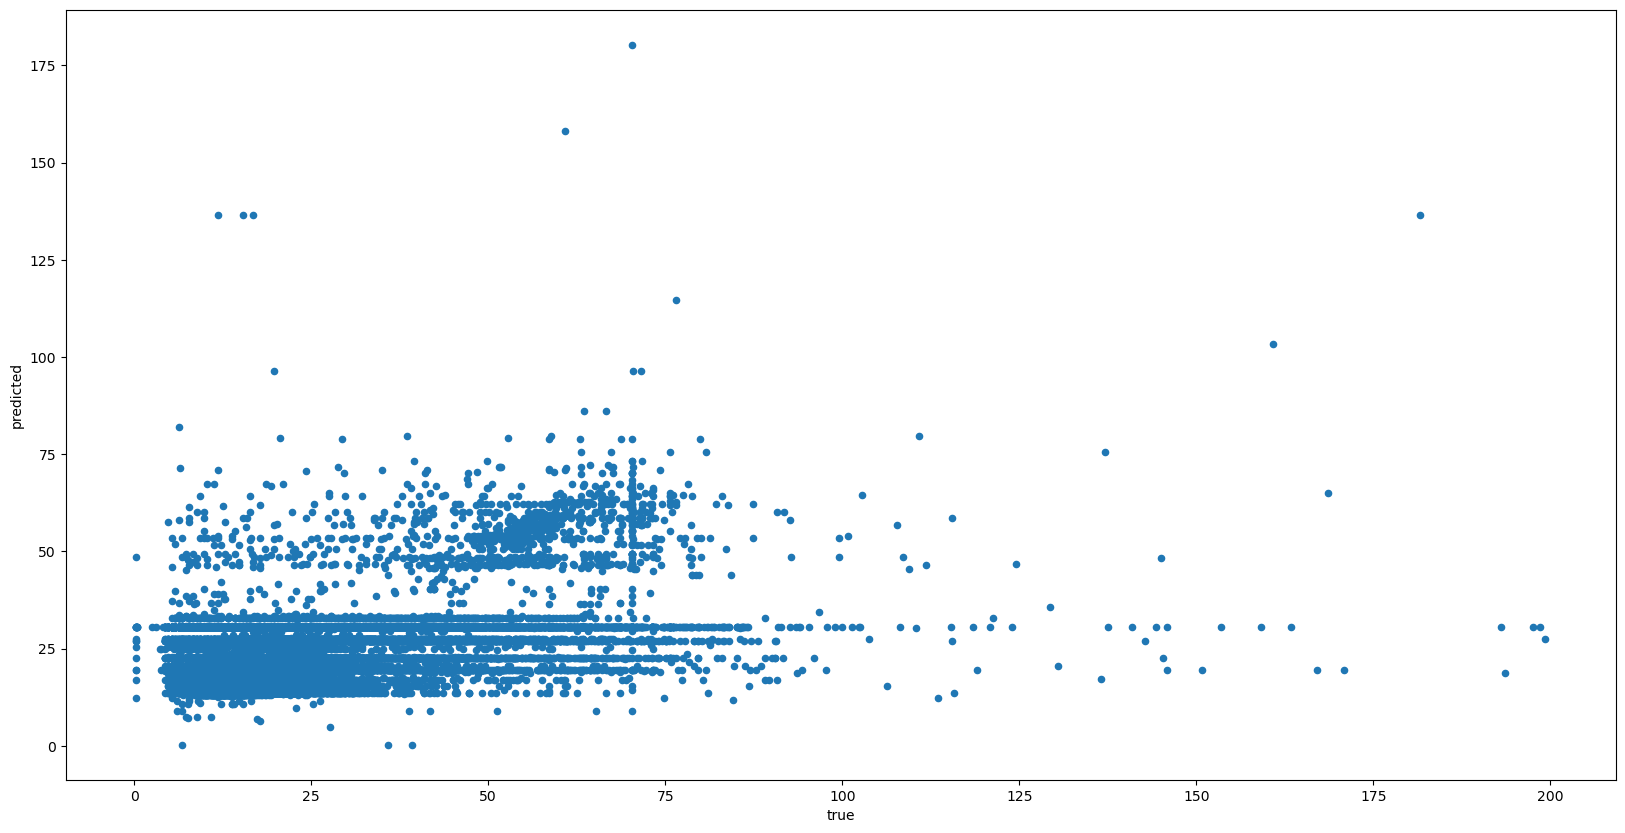

In [97]:
data = { 'true': y_test, 'predicted': y_pred }
results = pd.DataFrame(data)

results.plot(figsize=(20, 10), kind='scatter', x='true', y='predicted')

# 7.2. Random forest <a id='random_forest'></a>  
[Back to top](#table_of_contents)

In [99]:
from sklearn.ensemble import RandomForestRegressor

rando_model = RandomForestRegressor()

rando_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [100]:
model_at_hand = rando_model

y_pred = model_at_hand.predict(X_test)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2_score', r2_score(y_test, y_pred))

mean_absolute_error 6.816856650572529
mean_squared_error 146.3958198477399
root_mean_squared_error 12.099414029106528
r2_score 0.37884304810503155


<Axes: xlabel='true', ylabel='predicted'>

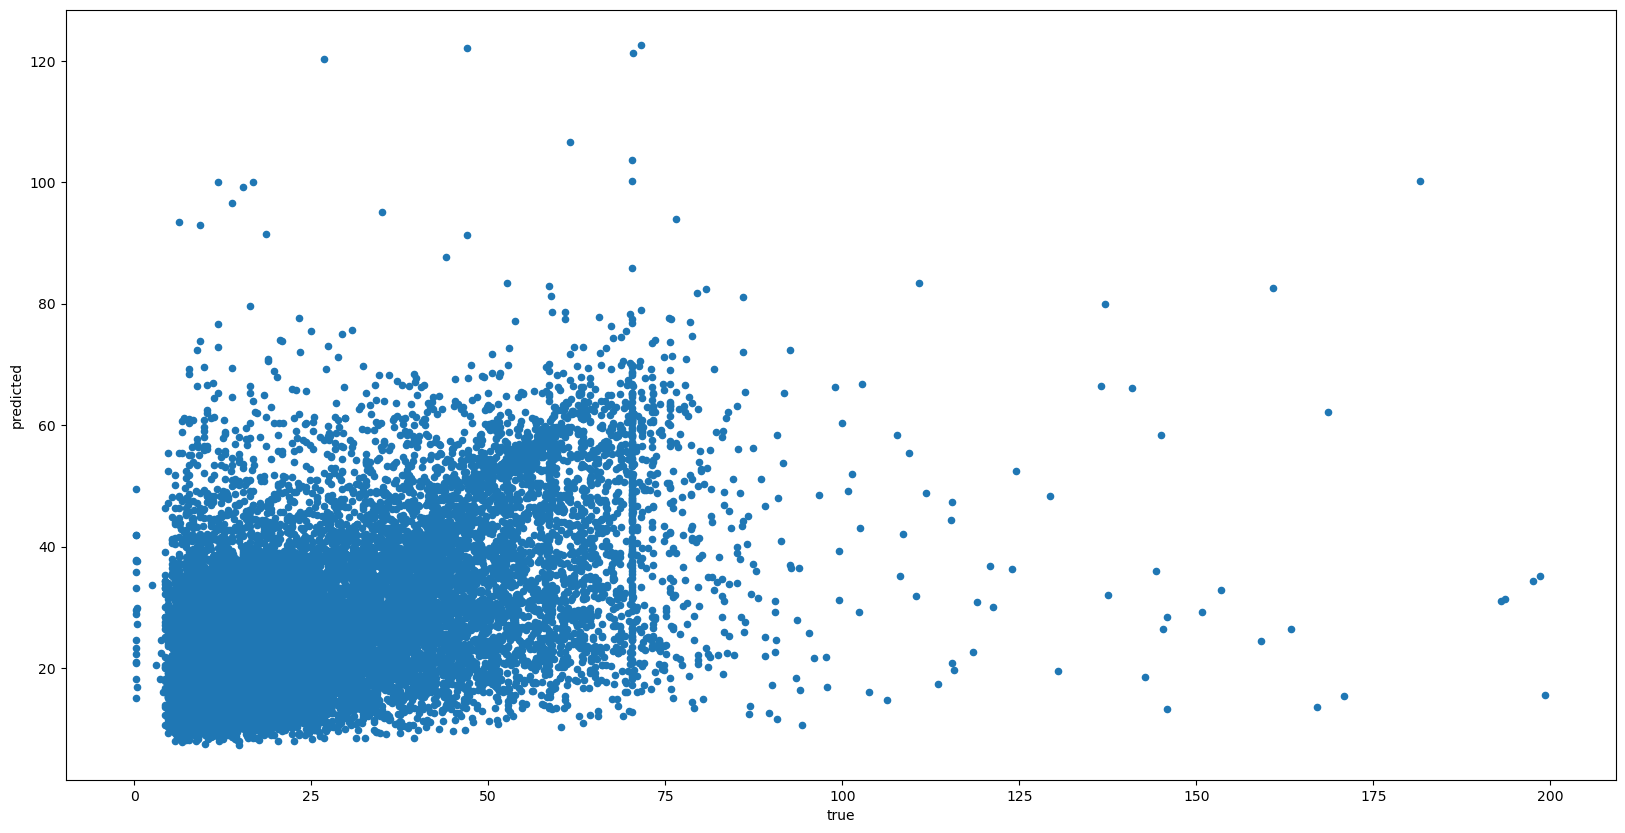

In [104]:
data = { 'true': y_test, 'predicted': y_pred }
results = pd.DataFrame(data)
results.plot(figsize=(20, 10), kind='scatter', x='true', y='predicted')

# 7.3. Gradient boosting <a id='gradient_boosting'></a>  
[Back to top](#table_of_contents)

In [105]:
from sklearn.ensemble import GradientBoostingRegressor

gradBooster = GradientBoostingRegressor()
gradBooster.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [106]:
model_at_hand = gradBooster

y_pred = model_at_hand.predict(X_test)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2_score', r2_score(y_test, y_pred))

mean_absolute_error 7.772452331860939
mean_squared_error 149.8230147030584
root_mean_squared_error 12.24022118685191
r2_score 0.36430147231349697


<Axes: xlabel='true', ylabel='predicted'>

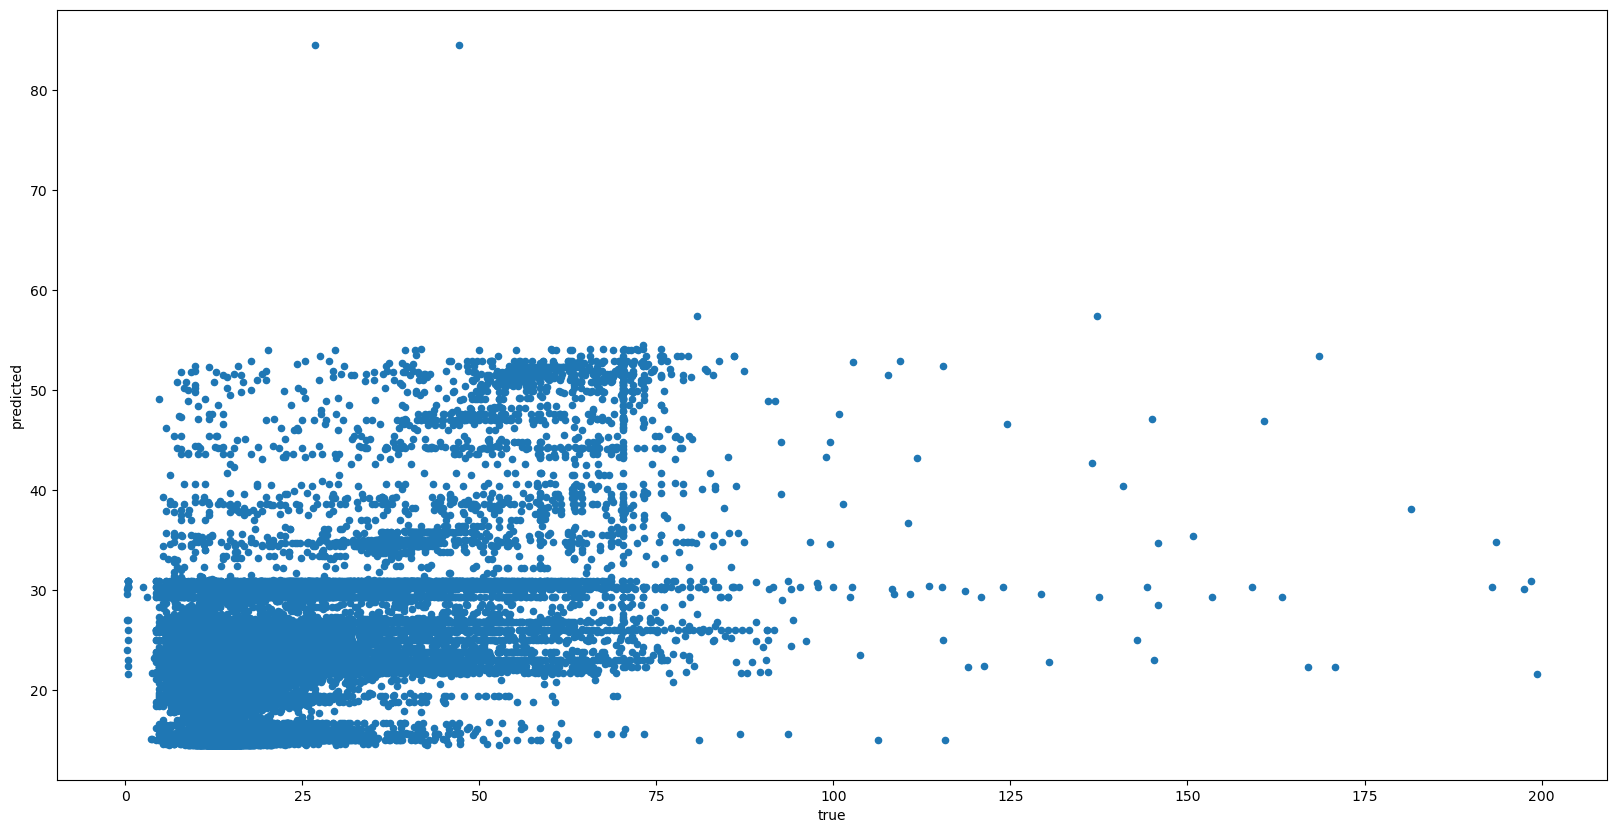

In [107]:
data = { 'true': y_test, 'predicted': y_pred }
results = pd.DataFrame(data)

results.plot(figsize=(20, 10), kind='scatter', x='true', y='predicted')

In [2]:
(pd.Series(model_at_hand.feature_importances_, index=X_train.columns)
    .nlargest(10)
    .plot(kind='barh'))

NameError: name 'pd' is not defined

# 8. Tuning <a id='tuning'></a>  
[Back to top](#table_of_contents)

# 8.1. Find best parameters <a id='find_best_parameters'></a>  
[Back to top](#table_of_contents)

In [110]:
n_estimators = [int(x) for x in np.linspace(start=200, stop=2000, num=10)]

max_features = ['auto', 'sqrt']

max_depth = [10,20,50,100,150,200,300,500]
max_depth.append(None)

min_samples_split = [2, 5, 10, 20, 40]

min_samples_leaf = [1, 2, 4, 10, 20]

bootstrap = [True, False]

In [111]:
import pprint as pp

random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
pp.pprint(random_grid)

{'bootstrap': [True, False],
 'max_depth': [10, 20, 50, 100, 150, 200, 300, 500, None],
 'max_features': ['auto', 'sqrt'],
 'min_samples_leaf': [1, 2, 4, 10, 20],
 'min_samples_split': [2, 5, 10, 20, 40],
 'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]}


In [112]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor()

rf_random = RandomizedSearchCV(estimator=rf, param_distributions=random_grid, n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1)

rf_random.fit(X_train, y_train)

performances = pd.DataFrame.from_dict(rf_random.cv_results_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=  13.1s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=  13.5s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=  13.5s
[CV] END bootstrap=False, max_depth=20, max_features=auto, min_samples_leaf=10, min_samples_split=40, n_estimators=400; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, max_features=auto, min_samples_leaf=10, min_samples_split=40, n_estimators=400; total time=   0.1s
[CV] END bootstrap=False, max_depth=20, max_features=auto, min_samples_leaf=10, min_samples_split=40, n_estimators=400; total time=   0.2s
[CV] END bootstrap=False, max_depth=50, max_features=auto, min_samples_leaf=20, min_samples_split=20, n_estimators

/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
9 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 471, in _validate_params
  

In [114]:
performances

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_features,param_max_depth,param_bootstrap,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,42.580487,0.311417,2.789549,0.040634,200,10,1,sqrt,200,False,"{'n_estimators': 200, 'min_samples_split': 10,...",0.413242,0.402232,0.408283,0.407919,0.004502,3
1,12.795516,0.127013,0.580117,0.067104,200,5,4,sqrt,20,True,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.361084,0.353113,0.363423,0.359206,0.004413,5
2,16.216853,0.201264,0.605504,0.038763,200,40,4,sqrt,20,False,"{'n_estimators': 200, 'min_samples_split': 40,...",0.359546,0.348814,0.363355,0.357238,0.006156,6
3,0.096738,0.048611,0.000000,0.000000,400,40,10,auto,20,False,"{'n_estimators': 400, 'min_samples_split': 40,...",NaN,NaN,NaN,NaN,NaN,8
4,0.057991,0.010170,0.000000,0.000000,1000,20,20,auto,50,False,"{'n_estimators': 1000, 'min_samples_split': 20...",NaN,NaN,NaN,NaN,NaN,8
5,279.129322,0.561363,43.849354,0.249929,1200,5,1,sqrt,100,False,"{'n_estimators': 1200, 'min_samples_split': 5,...",0.374698,0.366200,0.362477,0.367792,0.005114,4
6,40.647535,1.789058,1.529344,0.306725,1400,5,20,sqrt,10,True,"{'n_estimators': 1400, 'min_samples_split': 5,...",0.265811,0.261465,0.267464,0.264913,0.002530,7
7,151.171346,3.452521,12.671211,2.339650,1400,10,10,sqrt,None,True,"{'n_estimators': 1400, 'min_samples_split': 10...",0.413586,0.404434,0.414685,0.410902,0.004595,2
8,0.062503,0.004529,0.000000,0.000000,1800,10,2,auto,50,False,"{'n_estimators': 1800, 'min_samples_split': 10...",NaN,NaN,NaN,NaN,NaN,8
9,115.869480,19.492798,8.299128,2.894064,600,10,2,sqrt,500,False,"{'n_estimators': 600, 'min_samples_split': 10,...",0.429318,0.415798,0.423506,0.422874,0.005538,1


In [115]:
rf_random.best_params_

{'n_estimators': 600,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 500,
 'bootstrap': False}

In [116]:
import time
t0 =time.time()

best = RandomForestRegressor(n_estimators=1800, min_samples_split=2,
min_samples_leaf=4,
max_features='sqrt',
max_depth=300,
bootstrap=True)
best.fit(X_train, y_train)

t1 = time.time() - t0
print("Time elapsed: ", t1, " seconds")

model_at_hand = best

y_pred = model_at_hand.predict(X_test)

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2_score', r2_score(y_test, y_pred))

Time elapsed:  147.95997500419617  seconds
mean_absolute_error 6.7174594289018845
mean_squared_error 131.56970185705705
root_mean_squared_error 11.470383683951338
r2_score 0.44175021491557265


In [117]:
from sklearn.ensemble import RandomForestRegressor

import time
t0= time.time()

second_best = RandomForestRegressor(n_estimators=200,min_samples_split= 10,
min_samples_leaf= 2,
max_features= 'sqrt',
max_depth= 150,
bootstrap= True)
second_best.fit(X_train, y_train)

t1 = time.time() - t0
print("Time elapsed: ", t1, " seconds")


model_at_hand = second_best

y_pred = model_at_hand.predict(X_test)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from math import sqrt

print('mean_absolute_error', mean_absolute_error(y_test, y_pred))
print('mean_squared_error', mean_squared_error(y_test, y_pred))
print('root_mean_squared_error', sqrt(mean_squared_error(y_test, y_pred)))
print('r2', r2_score(y_test, y_pred))



Time elapsed:  17.01318120956421  seconds
mean_absolute_error 6.624537694994472
mean_squared_error 130.6454103099472
root_mean_squared_error 11.430022323247982
r2 0.4456719807191466


<Axes: xlabel='true', ylabel='predicted'>

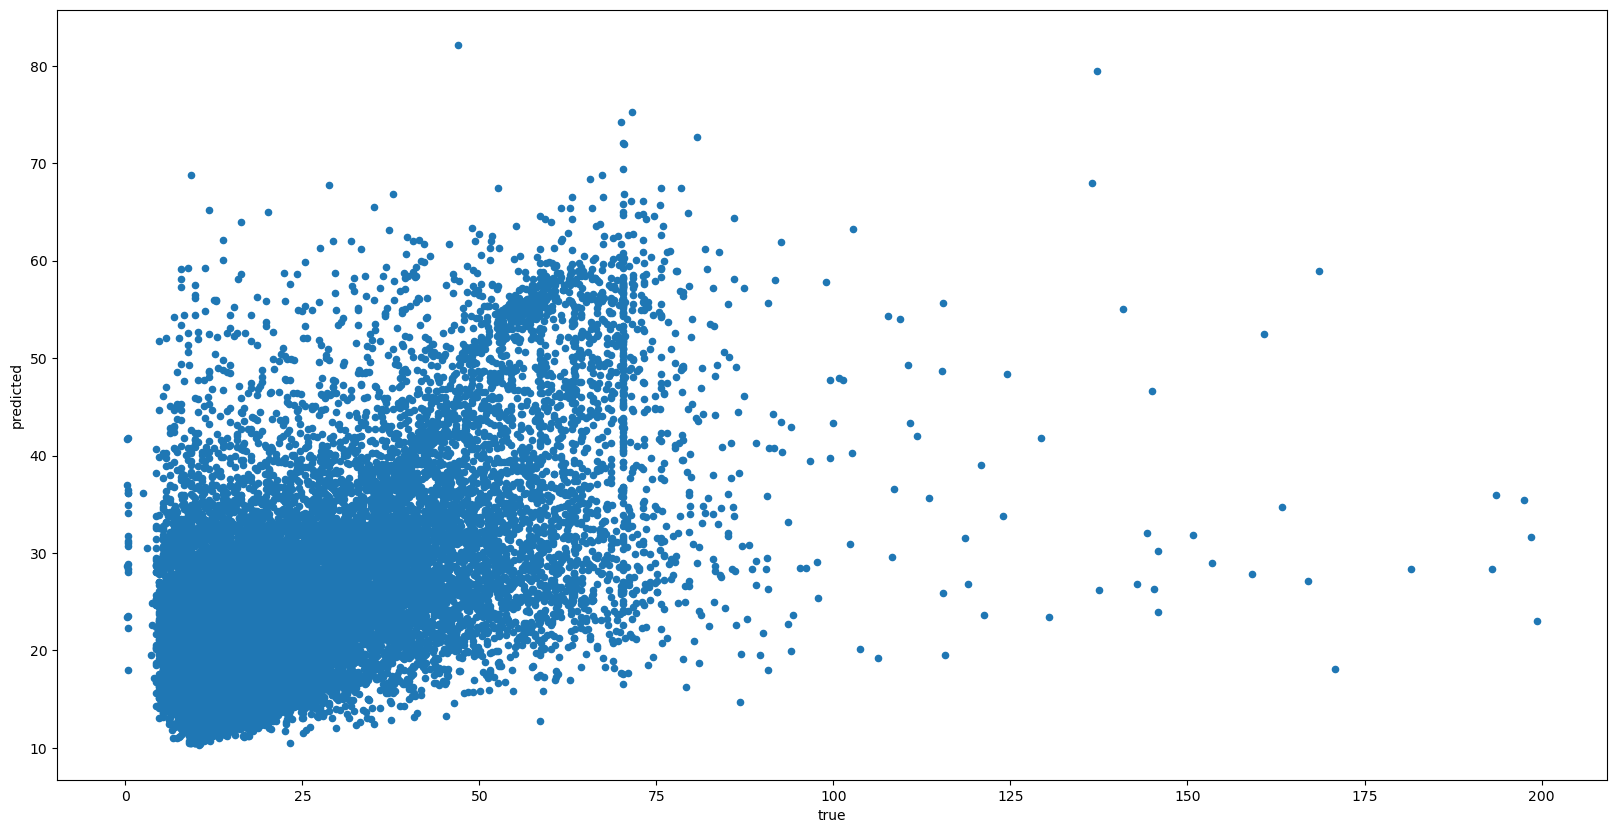

In [118]:
data = { 'true': y_test, 'predicted': y_pred }
results = pd.DataFrame(data)

results.plot(figsize=(20, 10), kind='scatter', x='true', y='predicted')

# Classification <a id='classification'></a>  
[Back to top](#table_of_contents)

<Axes: >

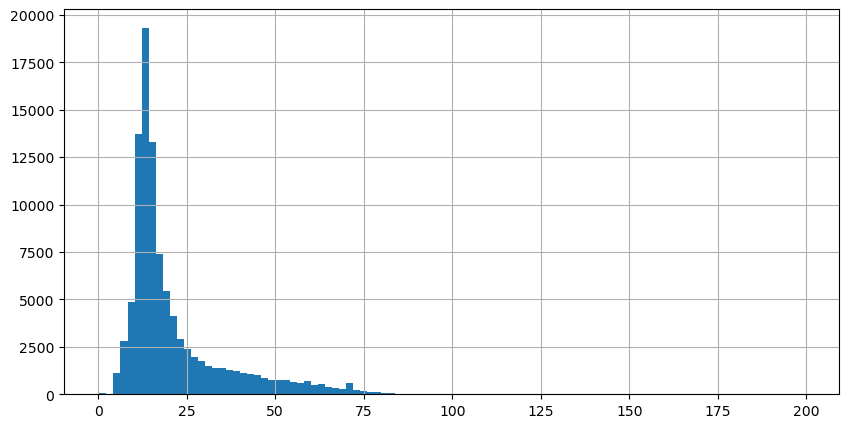

In [119]:
nyc_taxi_with_weather['total_amount'].hist(bins=100, figsize=(10, 5))

In [120]:
nyc_class = nyc_taxi_with_weather.copy()
nyc_class['earning_class'] = nyc_taxi_with_weather['total_amount'].apply(lambda x: 'low' if x <= 15 else 'high')
nyc_class['earning_class_binary'] = nyc_class['earning_class'].apply(lambda x: 0 if x == 'low' else 1)
nyc_class.head()

,PULocationID,transaction_year,transaction_month,transaction_day,transaction_hour,transaction_weekday,transaction_date,trip_distance,total_amount,count_of_transactions,is_holiday,LocationID,Borough,temperature,humidity,wind speed,cloud cover,amount of precipitation,earning_class,earning_class_binary
0,10,2019,1,1,0,1,2019-01-01,3.020000,14.300000,2,True,10,Queens,8.3,97.0,0.0,1.0,29.0,low,0
1,100,2019,1,1,0,1,2019-01-01,2.801852,18.130000,54,True,100,Manhattan,8.3,97.0,0.0,1.0,29.0,high,1
2,106,2019,1,1,0,1,2019-01-01,2.593333,15.373333,3,True,106,Brooklyn,8.3,97.0,0.0,1.0,29.0,high,1
3,107,2019,1,1,0,1,2019-01-01,2.381655,14.716326,411,True,107,Manhattan,8.3,97.0,0.0,1.0,29.0,low,0
4,11,2019,1,1,0,1,2019-01-01,1.795000,9.300000,2,True,11,Brooklyn,8.3,97.0,0.0,1.0,29.0,low,0


In [121]:
nyc_class['earning_class'].value_counts()

earning_class
high    51665
low     48281
Name: count, dtype: int64

In [122]:
categorical_features = ['PULocationID', 'transaction_month', 'transaction_day', 'transaction_hour', 'transaction_weekday', 'is_holiday', 'Borough']

input_features = categorical_features + ['temperature', 'humidity', 'wind speed', 'cloud cover', 'amount of precipitation']

target_feature = 'earning_class_binary'

In [124]:
from sklearn.model_selection import train_test_split

X_c = nyc_class[input_features]
y_c = nyc_class[target_feature]

X_c = pd.get_dummies(X_c)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.33, random_state=42)

In [125]:
from sklearn.ensemble import RandomForestRegressor

clf = RandomForestRegressor()
clf.fit(X_train_c, y_train_c)

y_pred_c = clf.predict(X_test_c)

In [129]:
# Suppose you made y_test_c by thresholding true fares:
# y_test_c = (y_test > 20).astype(int)  # example

# If model is a regressor, convert predictions to classes the same way:
y_pred_cont = model_at_hand.predict(X_test_c)     # continuous preds
y_pred_c = (y_pred_cont > 20).astype(int)         # same threshold

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

print(confusion_matrix(y_test_c, y_pred_c))
print('accuracy', accuracy_score(y_test_c, y_pred_c))
print('precision', precision_score(y_test_c, y_pred_c))
print('recall', recall_score(y_test_c, y_pred_c))

[[12922  2987]
 [ 6408 10666]]
accuracy 0.7151562926356002
precision 0.7812202446348788
recall 0.6246925149349889


<Axes: >

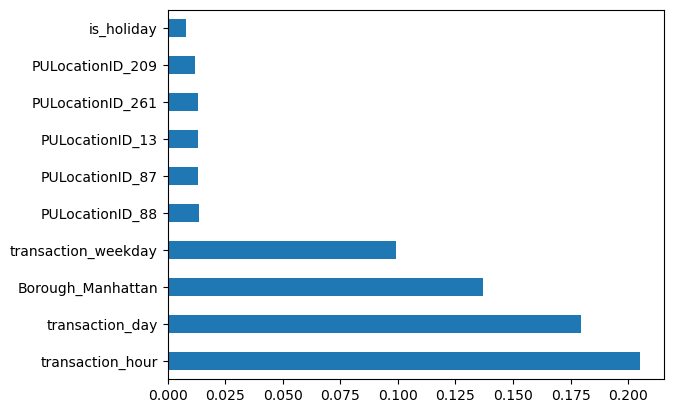

In [132]:
(pd.Series(clf.feature_importances_, index=X_train.columns)
   .nlargest(10)
   .plot(kind='barh')) 